In [98]:
from qiskit import transpile
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.layout import SabreLayout, SetLayout, TrivialLayout, ApplyLayout
from qiskit.transpiler.passes.routing import SabreSwap
from qiskit.transpiler import CouplingMap
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.layout import Layout
from qiskit.circuit.library.standard_gates import SwapGate, CXGate


seed = 12345

# Define the coupling map of the target backend
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]])

# quantum circuit
q = QuantumRegister(5, 'q')

your_quantum_circuit =  QuantumCircuit(q)

# G1
your_quantum_circuit.cx(q[0],q[3]) 
# G2
your_quantum_circuit.cx(q[1],q[4])
# G3
your_quantum_circuit.cx(q[2],q[3])
# G4
your_quantum_circuit.cx(q[1],q[2])




# SABRESwap object with Basic heuristic
sabre_swap_basic = SabreSwap(coupling_map, heuristic='basic')

# SABRESwap object with Lookahead heuristic
sabre_swap_lookahead = SabreSwap(coupling_map, heuristic='lookahead')

# SABRESwap object with Decay heuristic
sabre_swap_decay = SabreSwap(coupling_map, heuristic='decay')

# trivial layout
initial_layout = Layout(
{   
    your_quantum_circuit.qubits[0]: 0, 
    your_quantum_circuit.qubits[1]: 1, 
    your_quantum_circuit.qubits[2]: 2, 
    your_quantum_circuit.qubits[3]: 3, 
    your_quantum_circuit.qubits[4]: 4
}
)


# Set up the SabreLayout and SabreSwap passes
sabre_layout = SabreLayout(coupling_map, seed=4)

# With the Trivial mapping algorithm

#Passmanager for the SabreSwap with basic H
pass_manager_basic = PassManager()
# pass_manager_basic.append(log_intermediate_layouts)
pass_manager_basic.append(SetLayout(initial_layout))
pass_manager_basic.append(ApplyLayout())
pass_manager_basic.append(sabre_swap_basic)

#Passmanager for the SabreSwap with Lookahead H
pass_manager_lookahead = PassManager()
pass_manager_lookahead.append(SetLayout(initial_layout))
pass_manager_lookahead.append(ApplyLayout())
pass_manager_lookahead.append(sabre_swap_lookahead)

#Passmanager for the SabreSwap with decay H
pass_manager_decay = PassManager()
pass_manager_decay.append(SetLayout(initial_layout))
pass_manager_decay.append(ApplyLayout())
pass_manager_decay.append(sabre_swap_decay)

# With the SabreLayout mapping algorithm

#Passmanager for the SabreSwap with basic H
pm_basic_sabre_layout = PassManager()
pm_basic_sabre_layout.append(sabre_layout)
pm_basic_sabre_layout.append(sabre_swap_basic)

#Passmanager for the SabreSwap with Lookahead H
pm_lookahead_sabre_layout = PassManager()
pm_lookahead_sabre_layout.append(sabre_layout)
pm_lookahead_sabre_layout.append(sabre_swap_lookahead)

#Passmanager for the SabreSwap with decay H
pm_decay_sabre_layout = PassManager()
pm_decay_sabre_layout.append(sabre_layout)
pm_decay_sabre_layout.append(sabre_swap_decay)




In [99]:
## circuit 1 with the basic H optimization on trivial mapping
translated_basic = pass_manager_basic.run(your_quantum_circuit)


print(your_quantum_circuit)
swap_gates = []
cx_gates = []
for gate, qargs, _ in translated_basic.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))



initial_layout_result = pass_manager_basic.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager_basic.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
print(final_layout)
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")


print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)


q_0: ──■─────────────────
       │                 
q_1: ──┼────■─────────■──
       │    │       ┌─┴─┐
q_2: ──┼────┼────■──┤ X ├
     ┌─┴─┐  │  ┌─┴─┐└───┘
q_3: ┤ X ├──┼──┤ X ├─────
     └───┘┌─┴─┐└───┘     
q_4: ─────┤ X ├──────────
          └───┘          
Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
1: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
3: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 1
q 2 -> Q 2
q 3 -> Q 3
q 4 -> Q 4
Final mapping of virtual to physical qubits:
Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
3: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
1: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
q 0 -> Q 0
q 1 -> Q 3
q 2 -> Q 2
q 3 -> Q 1
q 4 -> Q 4
SWAP operations used: [(3, 2), (1, 2), (2, 3)]
CX operations used: [(0, 1), (2, 1), (3, 4), (3, 2)]


In [35]:
## circuit 1 with the lookahead H optimization on trivial mapping
translated_lookahead = pass_manager_lookahead.run(your_quantum_circuit)

swap_gates = []
cx_gates = []
for gate, qargs, _ in translated_lookahead.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))



initial_layout_result = pass_manager_lookahead.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager_lookahead.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
print(final_layout)
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")


print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)

Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
1: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
3: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 1
q 2 -> Q 2
q 3 -> Q 3
q 4 -> Q 4
Final mapping of virtual to physical qubits:
Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
3: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
1: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
q 0 -> Q 0
q 1 -> Q 3
q 2 -> Q 2
q 3 -> Q 1
q 4 -> Q 4
SWAP operations used: [(1, 2), (2, 3), (2, 1)]
CX operations used: [(0, 1), (2, 1), (3, 4), (3, 2)]


In [36]:
## circuit 1 with the decay H optimization on trivial mapping
translated_decay = pass_manager_decay.run(your_quantum_circuit)

swap_gates = []
cx_gates = []
for gate, qargs, _ in translated_decay.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))


initial_layout_result = pass_manager_decay.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager_decay.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
print(final_layout)
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")


print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)

Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
1: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
3: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 1
q 2 -> Q 2
q 3 -> Q 3
q 4 -> Q 4
Final mapping of virtual to physical qubits:
Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
3: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
1: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
q 0 -> Q 0
q 1 -> Q 3
q 2 -> Q 2
q 3 -> Q 1
q 4 -> Q 4
SWAP operations used: [(3, 2), (1, 2), (2, 3)]
CX operations used: [(0, 1), (2, 1), (3, 4), (3, 2)]


In [96]:
# Circuit 1 with basic H on SabreLayout mapping
trans_optimized_basic = pm_basic_sabre_layout.run(your_quantum_circuit)

swap_gates = []
cx_gates = []
for gate, qargs, _ in trans_optimized_basic.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))

initial_layout_result = pm_basic_sabre_layout.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pm_basic_sabre_layout.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
print(final_layout)
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)

Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
3: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
1: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 3
q 2 -> Q 2
q 3 -> Q 1
q 4 -> Q 4
Final mapping of virtual to physical qubits:
Layout({
0: Qubit(QuantumRegister(5, 'q'), 0),
1: Qubit(QuantumRegister(5, 'q'), 1),
2: Qubit(QuantumRegister(5, 'q'), 2),
3: Qubit(QuantumRegister(5, 'q'), 3),
4: Qubit(QuantumRegister(5, 'q'), 4)
})
q 0 -> Q 0
q 1 -> Q 1
q 2 -> Q 2
q 3 -> Q 3
q 4 -> Q 4
SWAP operations used: []
CX operations used: [(0, 1), (2, 1), (3, 4), (3, 2)]


In [61]:
from qiskit.circuit.library.standard_gates import SwapGate, CXGate 
from qiskit.transpiler.passes.layout import ApplyLayout

import numpy as np

# Set a random seed for reproducibility
seed = 123678

coupling_map = CouplingMap([
        [0, 1], [0, 3], 
        [1, 0], [1, 2], [1, 4], 
        [2, 1], [2, 5],
        [3, 0], [3, 4], [3, 6],
        [4, 1], [4, 3], [4, 5], [4, 7],
        [5, 2], [5, 4], [5, 8],
        [6, 3], [6, 7],
        [7, 4], [7, 6], [7, 8],
        [8, 5], [8, 7]
        ]
)

q = QuantumRegister(9, 'q')


qc = QuantumCircuit(q)

qc.cx(q[0], q[1])
qc.cx(q[2], q[3])


initial_layout = Layout(
{   
    qc.qubits[0]: 6, 
    qc.qubits[1]: 1, 
    qc.qubits[2]: 7, 
    qc.qubits[3]: 2,
    qc.qubits[4]: 3, 
    qc.qubits[5]: 0, 
    qc.qubits[6]: 8, 
    qc.qubits[7]: 5,
    qc.qubits[8]: 4
}
)
# print(initial_layout)
# sabre_swap_basic = SabreSwap(coupling_map, heuristic='decay', seed=seed)
sabre_swap_decay = SabreSwap(coupling_map, heuristic='decay')

sabre_layout = SabreLayout(coupling_map=coupling_map, seed=1)


# circuit 2 with decay H with initial mapping.
pass_manager = PassManager()
pass_manager.append(SetLayout(initial_layout))
pass_manager.append(ApplyLayout())
pass_manager.append(sabre_swap_decay)



translated = pass_manager.run(qc)

swap_gates = []
cx_gates = []
for gate, qargs, _ in translated.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))



initial_layout_result = pass_manager.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")




print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)
coupling_map.draw()

circuit_2 = translated


Layout({
6: Qubit(QuantumRegister(9, 'q'), 0),
1: Qubit(QuantumRegister(9, 'q'), 1),
7: Qubit(QuantumRegister(9, 'q'), 2),
2: Qubit(QuantumRegister(9, 'q'), 3),
3: Qubit(QuantumRegister(9, 'q'), 4),
0: Qubit(QuantumRegister(9, 'q'), 5),
8: Qubit(QuantumRegister(9, 'q'), 6),
5: Qubit(QuantumRegister(9, 'q'), 7),
4: Qubit(QuantumRegister(9, 'q'), 8)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 6
q 1 -> Q 1
q 2 -> Q 7
q 3 -> Q 2
q 4 -> Q 3
q 5 -> Q 0
q 6 -> Q 8
q 7 -> Q 5
q 8 -> Q 4
Final mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 4
q 2 -> Q 5
q 3 -> Q 6
q 4 -> Q 1
q 5 -> Q 2
q 6 -> Q 3
q 7 -> Q 8
q 8 -> Q 7
SWAP operations used: [(1, 4), (2, 5), (6, 3), (7, 8)]
CX operations used: [(3, 4), (8, 5)]


In [93]:
sabre_swap_basic = SabreSwap(coupling_map, heuristic='basic')


pass_manager_basic = PassManager()
pass_manager_basic.append(SetLayout(initial_layout))
pass_manager_basic.append(ApplyLayout())
pass_manager_basic.append(sabre_swap_basic)


# circuit 2 with basic H with initial mapping. 

translated_basic = pass_manager_basic.run(qc)

swap_gates = []
cx_gates = []
for gate, qargs, _ in translated_basic.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))



initial_layout_result = pass_manager_basic.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager_basic.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")




print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)
coupling_map.draw()
circuit_2_basic = translated_basic

Layout({
6: Qubit(QuantumRegister(9, 'q'), 0),
1: Qubit(QuantumRegister(9, 'q'), 1),
7: Qubit(QuantumRegister(9, 'q'), 2),
2: Qubit(QuantumRegister(9, 'q'), 3),
3: Qubit(QuantumRegister(9, 'q'), 4),
0: Qubit(QuantumRegister(9, 'q'), 5),
8: Qubit(QuantumRegister(9, 'q'), 6),
5: Qubit(QuantumRegister(9, 'q'), 7),
4: Qubit(QuantumRegister(9, 'q'), 8)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 6
q 1 -> Q 1
q 2 -> Q 7
q 3 -> Q 2
q 4 -> Q 3
q 5 -> Q 0
q 6 -> Q 8
q 7 -> Q 5
q 8 -> Q 4
Final mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 7
q 2 -> Q 1
q 3 -> Q 3
q 4 -> Q 2
q 5 -> Q 5
q 6 -> Q 6
q 7 -> Q 4
q 8 -> Q 8
SWAP operations used: [(1, 4), (2, 1), (4, 7)]
CX operations used: [(4, 1), (6, 7)]


Layout({
5: Qubit(QuantumRegister(9, 'q'), 0),
2: Qubit(QuantumRegister(9, 'q'), 1),
1: Qubit(QuantumRegister(9, 'q'), 2),
0: Qubit(QuantumRegister(9, 'q'), 3),
4: Qubit(QuantumRegister(9, 'q'), 4),
8: Qubit(QuantumRegister(9, 'q'), 5),
7: Qubit(QuantumRegister(9, 'q'), 6),
6: Qubit(QuantumRegister(9, 'q'), 7),
3: Qubit(QuantumRegister(9, 'q'), 8)
})
Initial mapping of virtual to physical qubits:
q 0 -> Q 5
q 1 -> Q 2
q 2 -> Q 1
q 3 -> Q 0
q 4 -> Q 4
q 5 -> Q 8
q 6 -> Q 7
q 7 -> Q 6
q 8 -> Q 3
Final mapping of virtual to physical qubits:
q 0 -> Q 0
q 1 -> Q 1
q 2 -> Q 2
q 3 -> Q 3
q 4 -> Q 4
q 5 -> Q 5
q 6 -> Q 6
q 7 -> Q 7
q 8 -> Q 8
SWAP operations used: []
CX operations used: [(1, 0), (5, 2)]


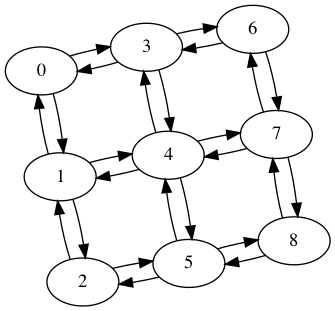

In [26]:
sabre_swap_basic = SabreSwap(coupling_map, heuristic='basic')


pass_manager_basic = PassManager()
pass_manager_basic.append(sabre_layout)
pass_manager_basic.append(sabre_swap_basic)


translated_basic = pass_manager_basic.run(qc)

swap_gates = []
cx_gates = []
for gate, qargs, _ in translated_basic.data:
    if isinstance(gate, SwapGate):
        swap_gates.append((q.index(qargs[0]), q.index(qargs[1])))
    if isinstance(gate, CXGate):
        cx_gates.append((q.index(qargs[0]), q.index(qargs[1])))



initial_layout_result = pass_manager_basic.property_set['layout']
print(initial_layout_result)

print("Initial mapping of virtual to physical qubits:")
for virtual, physical in initial_layout_result.get_virtual_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")

final_layout = pass_manager_basic.property_set['final_layout']
print("Final mapping of virtual to physical qubits:")
for physical, virtual in final_layout.get_physical_bits().items():
    print(f"q {q.index(virtual)} -> Q {physical}")




print("SWAP operations used:", swap_gates)
print("CX operations used:", cx_gates)
coupling_map.draw()

In [100]:
# basic for circuit 1
print("basic H for circuit 1")
print(translated_basic)


# lookahead for circuit 1
print("lookahead H for circuit 1")
print(translated_lookahead)

# decay for circuit 1
print("decay H for circuit 1")
print(translated_decay)

# circuit_2 with decay H
print("decay H for circuit 2")
print(circuit_2)

# circuit_2 with Basic H
print("basic H for circuit 2")
print(circuit_2_basic)

basic H for circuit 1
                              
q_0 -> 0 ────────■────────────
               ┌─┴─┐┌───┐     
q_1 -> 1 ────X─┤ X ├┤ X ├─────
             │ └───┘└─┬─┘┌───┐
q_2 -> 2 ─X──X───X────■──┤ X ├
          │      │       └─┬─┘
q_3 -> 3 ─X──────X────■────■──
                    ┌─┴─┐     
q_4 -> 4 ───────────┤ X ├─────
                    └───┘     
lookahead H for circuit 1
                                   
q_0 -> 0 ─────────────■────────────
                    ┌─┴─┐┌───┐     
q_1 -> 1 ─X──────X──┤ X ├┤ X ├─────
          │      │  └───┘└─┬─┘┌───┐
q_2 -> 2 ─X──X───X─────────■──┤ X ├
             │                └─┬─┘
q_3 -> 3 ────X───■──────────────■──
               ┌─┴─┐               
q_4 -> 4 ──────┤ X ├───────────────
               └───┘               
decay H for circuit 1
                              
q_0 -> 0 ────────■────────────
               ┌─┴─┐┌───┐     
q_1 -> 1 ────X─┤ X ├┤ X ├─────
             │ └───┘└─┬─┘┌───┐
q_2 -> 2 ─X──X───X────■──┤ X ├
       